In [1]:
import argparse
from typing import Sequence

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

import ioptics as iop
import utils

In [2]:
class OpticalConv2d(nn.Module):
    def __init__(
        self,
        kernel_size: int = 2,
        stride: int = 1,
        use_activation: bool = True,
        activation: nn.Module | None = None,
    ):
        super().__init__()
        if kernel_size <= 0:
            raise ValueError(f"kernel_size must be positive, got {kernel_size}")
        if stride <= 0:
            raise ValueError(f"stride must be positive, got {stride}")

        self.kernel_size = kernel_size
        self.stride = stride
        self.use_activation = use_activation
        self.activation = activation if activation is not None else iop.SquareActivation()
        self.optical_kernel = iop.FCArray(in_dim=kernel_size * kernel_size, out_dim=1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        if x.ndim != 4 or x.shape[1] != 1:
            raise ValueError(f"Expected x shape (B,1,H,W), got {tuple(x.shape)}")

        batch_size, _, height, width = x.shape
        out_h = (height - self.kernel_size) // self.stride + 1
        out_w = (width - self.kernel_size) // self.stride + 1
        if out_h <= 0 or out_w <= 0:
            raise ValueError(
                f"Invalid output shape with input {(height, width)}, kernel_size={self.kernel_size}, stride={self.stride}"
            )

        patches = F.unfold(x, kernel_size=self.kernel_size, stride=self.stride)
        patches = patches.transpose(1, 2).to(torch.complex64)
        conv_out = self.optical_kernel(patches)
        conv_map = conv_out.transpose(1, 2).reshape(batch_size, 1, out_h, out_w)

        if self.use_activation:
            conv_map = self.activation(conv_map)

        return conv_map


class OpticalCNN(nn.Module):
    def __init__(
        self,
        input_size: tuple[int, int],
        num_classes: int,
        kernel_size: int = 2,
        stride: int = 1,
        use_activation: bool = True,
    ):
        super().__init__()
        self.conv = OpticalConv2d(
            kernel_size=kernel_size,
            stride=stride,
            use_activation=use_activation,
            activation=iop.SquareActivation(),
        )

        conv_h = (input_size[0] - kernel_size) // stride + 1
        conv_w = (input_size[1] - kernel_size) // stride + 1
        if conv_h <= 0 or conv_w <= 0:
            raise ValueError("Convolution output size must be positive")

        self.detector = iop.AbsSquared()
        self.classifier = iop.FCArray(in_dim=conv_h * conv_w, out_dim=num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.conv(x)
        x = self.detector(x)
        x = x.flatten(start_dim=1).to(torch.complex64)
        x = self.classifier(x)
        x = self.detector(x)
        return x.real


def parse_digits(digits_arg: str) -> Sequence[int]:
    digits = tuple(int(v.strip()) for v in digits_arg.split(",") if v.strip() != "")
    if len(digits) < 2:
        raise ValueError("Please provide at least two digits, e.g. '3,6'")
    if len(set(digits)) != len(digits):
        raise ValueError("digits must not contain duplicates")
    return digits


def evaluate(model: nn.Module, dataloader: DataLoader, criterion: nn.Module, device: torch.device) -> tuple[float, float]:
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_count = 0
    with torch.no_grad():
        for x_batch, y_batch in dataloader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
            logits = model(x_batch)
            loss = criterion(logits, y_batch)
            total_loss += loss.item() * x_batch.shape[0]
            total_correct += (logits.argmax(dim=1) == y_batch).sum().item()
            total_count += x_batch.shape[0]

    return total_loss / total_count, total_correct / total_count

In [3]:
seed = 42
digits = "3, 6"
target_size = (14, 14)
train_samples = 500
val_samples = 100
test_samples = 100
batch_size = 32
kernel_size = 2
stride = 1
no_activation = True
lr = 0.01
epochs = 10

In [4]:
torch.manual_seed(seed)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [5]:
digits = parse_digits(digits)

splits = utils.create_mnist_splits(
    train_samples=train_samples,
    val_samples=val_samples,
    test_samples=test_samples,
    digits=digits,
    target_size=target_size,
    normalize=True,
    seed=seed,
    shuffle=True,
    remap_labels=True,
    flatten=False,
)

train_x, train_y = splits["train"]
val_x, val_y = splits["val"]
test_x, test_y = splits["test"]

train_loader = DataLoader(TensorDataset(train_x.float(), train_y.long()), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(TensorDataset(val_x.float(), val_y.long()), batch_size=batch_size, shuffle=False)
test_loader = DataLoader(TensorDataset(test_x.float(), test_y.long()), batch_size=batch_size, shuffle=False)


In [6]:
model = OpticalCNN(
    input_size=target_size,
    num_classes=len(digits),
    kernel_size=kernel_size,
    stride=stride,
    use_activation=not no_activation,
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)


In [7]:
print(f"Device: {device}")
print(f"Digits: {digits} -> remapped labels [0, {len(digits)-1}]")
print(f"Activation enabled: {not no_activation} (default: SquareActivation)")

train_loss_history: list[float] = []
train_acc_history: list[float] = []
val_loss_history: list[float] = []
val_acc_history: list[float] = []

for epoch in range(1, epochs + 1):
    model.train()
    for x_batch, y_batch in train_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)
        optimizer.zero_grad()
        logits = model(x_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()

    train_loss, train_acc = evaluate(model, train_loader, criterion, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    train_loss_history.append(train_loss)
    train_acc_history.append(train_acc)
    val_loss_history.append(val_loss)
    val_acc_history.append(val_acc)

    print(
        f"Epoch {epoch:02d}/{epochs} | "
        f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}"
    )

test_loss, test_acc = evaluate(model, test_loader, criterion, device)
print(f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}")

Device: cpu
Digits: (3, 6) -> remapped labels [0, 1]
Activation enabled: False (default: SquareActivation)
Epoch 01/10 | Train Loss: 170.9900, Train Acc: 0.6340 | Val Loss: 108.8041, Val Acc: 0.6600
Epoch 02/10 | Train Loss: 63.7119, Train Acc: 0.8020 | Val Loss: 36.4292, Val Acc: 0.8500
Epoch 03/10 | Train Loss: 33.9918, Train Acc: 0.8760 | Val Loss: 20.8997, Val Acc: 0.9100
Epoch 04/10 | Train Loss: 24.7335, Train Acc: 0.9060 | Val Loss: 15.2013, Val Acc: 0.9200
Epoch 05/10 | Train Loss: 19.8175, Train Acc: 0.9240 | Val Loss: 12.0644, Val Acc: 0.9400
Epoch 06/10 | Train Loss: 16.7484, Train Acc: 0.9340 | Val Loss: 9.8232, Val Acc: 0.9400
Epoch 07/10 | Train Loss: 14.6424, Train Acc: 0.9400 | Val Loss: 8.7188, Val Acc: 0.9400
Epoch 08/10 | Train Loss: 12.9862, Train Acc: 0.9520 | Val Loss: 7.1490, Val Acc: 0.9400
Epoch 09/10 | Train Loss: 11.6906, Train Acc: 0.9580 | Val Loss: 6.5270, Val Acc: 0.9400
Epoch 10/10 | Train Loss: 10.5047, Train Acc: 0.9580 | Val Loss: 5.4675, Val Acc: 0.9

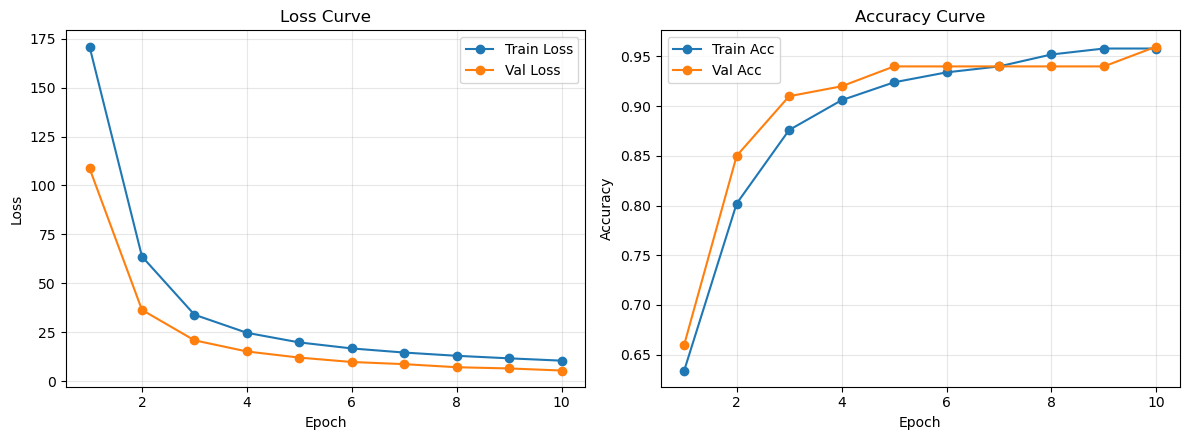

In [8]:
epochs_axis = list(range(1, epochs + 1))
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(epochs_axis, train_loss_history, marker="o", label="Train Loss")
axes[0].plot(epochs_axis, val_loss_history, marker="o", label="Val Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Loss Curve")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(epochs_axis, train_acc_history, marker="o", label="Train Acc")
axes[1].plot(epochs_axis, val_acc_history, marker="o", label="Val Acc")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Accuracy Curve")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

fig.tight_layout()
plt.show()
